In [1]:
import numpy as np
import pandas as pd
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GroupShuffleSplit
import os


# Подготовка датасета

In [2]:
file_path = './MixtureSolDB_with_features_small.csv'

df = pd.read_csv(file_path).dropna().reset_index(drop=True)

In [3]:
df

,Compound_Name,SMILES_Solute,Temperature_K,Solubility(mole_fraction),LogS(mole_fraction),Solvent1,Solvent2,SMILES_Solvent1,SMILES_Solvent2,x1,...,S2_RingCount,S2_NumAromaticRings,S2_FractionCSP3,S2_HeavyAtomCount,S2_BertzCT,S2_BalabanJ,S2_MaxPartialCharge,S2_MinPartialCharge,logS_linear,x1_times_x2
0,Rivastigmine tartrate,CCN(C)C(=O)Oc1cccc([C@H](C)N(C)C)c1.O=C(O)[C@H...,278.15,0.0872,-1.059484,acetonitrile,water,CC#N,O,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-1.059484,0.0
1,Rivastigmine tartrate,CCN(C)C(=O)Oc1cccc([C@H](C)N(C)C)c1.O=C(O)[C@H...,283.15,0.0983,-1.007446,acetonitrile,water,CC#N,O,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-1.007446,0.0
2,Rivastigmine tartrate,CCN(C)C(=O)Oc1cccc([C@H](C)N(C)C)c1.O=C(O)[C@H...,288.15,0.1126,-0.948462,acetonitrile,water,CC#N,O,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-0.948462,0.0
3,Rivastigmine tartrate,CCN(C)C(=O)Oc1cccc([C@H](C)N(C)C)c1.O=C(O)[C@H...,293.15,0.1287,-0.890421,acetonitrile,water,CC#N,O,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-0.890421,0.0
4,Rivastigmine tartrate,CCN(C)C(=O)Oc1cccc([C@H](C)N(C)C)c1.O=C(O)[C@H...,298.15,0.1469,-0.832978,acetonitrile,water,CC#N,O,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-0.832978,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117143,Glutaric acid,O=C(O)CCCC(=O)O,303.15,0.2683,-0.571379,ethanol,water,CCO,O,1.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-0.571379,0.0
117144,Glutaric acid,O=C(O)CCCC(=O)O,305.15,0.2769,-0.557677,ethanol,water,CCO,O,1.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-0.557677,0.0
117145,Glutaric acid,O=C(O)CCCC(=O)O,308.15,0.2964,-0.528122,ethanol,water,CCO,O,1.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-0.528122,0.0
117146,Glutaric acid,O=C(O)CCCC(=O)O,310.15,0.3081,-0.511308,ethanol,water,CCO,O,1.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-0.511308,0.0


In [4]:
df.columns

Index(['Compound_Name', 'SMILES_Solute', 'Temperature_K',
       'Solubility(mole_fraction)', 'LogS(mole_fraction)', 'Solvent1',
       'Solvent2', 'SMILES_Solvent1', 'SMILES_Solvent2', 'x1', 'x2',
       'IsPureSolventEndpoint', 'S1_pure_solubility', 'S1_pure_logS',
       'S1_temp_diff', 'S2_pure_solubility', 'S2_pure_logS', 'S2_temp_diff',
       'solute_MolWt', 'solute_MolLogP', 'solute_TPSA', 'solute_NumHDonors',
       'solute_NumHAcceptors', 'solute_NumRotatableBonds', 'solute_RingCount',
       'solute_NumAromaticRings', 'solute_FractionCSP3',
       'solute_HeavyAtomCount', 'solute_BertzCT', 'solute_BalabanJ',
       'solute_MaxPartialCharge', 'solute_MinPartialCharge', 'S1_MolWt',
       'S1_MolLogP', 'S1_TPSA', 'S1_NumHDonors', 'S1_NumHAcceptors',
       'S1_NumRotatableBonds', 'S1_RingCount', 'S1_NumAromaticRings',
       'S1_FractionCSP3', 'S1_HeavyAtomCount', 'S1_BertzCT', 'S1_BalabanJ',
       'S1_MaxPartialCharge', 'S1_MinPartialCharge', 'S2_MolWt', 'S2_MolLogP',
      

In [5]:
target_col = 'LogS(mole_fraction)'

drop_cols = [
    # target_col,
    'Solubility(mole_fraction)',
    'Compound_Name',
    'Solvent1',
    'Solvent2',
    'SMILES_Solute',
    'SMILES_Solvent1',
    'SMILES_Solvent2',
    
    'IsPureSolventEndpoint'

]

feature_cols = [c for c in df.columns if c not in drop_cols]

print("Number of features:", len(feature_cols))
print(feature_cols[:])

Number of features: 54
['Temperature_K', 'LogS(mole_fraction)', 'x1', 'x2', 'S1_pure_solubility', 'S1_pure_logS', 'S1_temp_diff', 'S2_pure_solubility', 'S2_pure_logS', 'S2_temp_diff', 'solute_MolWt', 'solute_MolLogP', 'solute_TPSA', 'solute_NumHDonors', 'solute_NumHAcceptors', 'solute_NumRotatableBonds', 'solute_RingCount', 'solute_NumAromaticRings', 'solute_FractionCSP3', 'solute_HeavyAtomCount', 'solute_BertzCT', 'solute_BalabanJ', 'solute_MaxPartialCharge', 'solute_MinPartialCharge', 'S1_MolWt', 'S1_MolLogP', 'S1_TPSA', 'S1_NumHDonors', 'S1_NumHAcceptors', 'S1_NumRotatableBonds', 'S1_RingCount', 'S1_NumAromaticRings', 'S1_FractionCSP3', 'S1_HeavyAtomCount', 'S1_BertzCT', 'S1_BalabanJ', 'S1_MaxPartialCharge', 'S1_MinPartialCharge', 'S2_MolWt', 'S2_MolLogP', 'S2_TPSA', 'S2_NumHDonors', 'S2_NumHAcceptors', 'S2_NumRotatableBonds', 'S2_RingCount', 'S2_NumAromaticRings', 'S2_FractionCSP3', 'S2_HeavyAtomCount', 'S2_BertzCT', 'S2_BalabanJ', 'S2_MaxPartialCharge', 'S2_MinPartialCharge', 'log

In [6]:
x_vars = []
solute_vars = []
free_vars = []
for col in feature_cols:
    if col.startswith('S1_'):
        name = col[3:]
        if name not in x_vars:
            x_vars.append(name)
            assert f'S2_{name}' in feature_cols

    elif col.startswith('S2_'):
        name = col[3:]
        if name not in x_vars:
            x_vars.append(name)
            assert f'S1_{name}' in feature_cols

    elif col.startswith('solute_'):
        solute_vars.append(col)
    else:
        free_vars.append(col)
        


In [7]:
x_vars, solute_vars, free_vars

(['pure_solubility',
  'pure_logS',
  'temp_diff',
  'MolWt',
  'MolLogP',
  'TPSA',
  'NumHDonors',
  'NumHAcceptors',
  'NumRotatableBonds',
  'RingCount',
  'NumAromaticRings',
  'FractionCSP3',
  'HeavyAtomCount',
  'BertzCT',
  'BalabanJ',
  'MaxPartialCharge',
  'MinPartialCharge'],
 ['solute_MolWt',
  'solute_MolLogP',
  'solute_TPSA',
  'solute_NumHDonors',
  'solute_NumHAcceptors',
  'solute_NumRotatableBonds',
  'solute_RingCount',
  'solute_NumAromaticRings',
  'solute_FractionCSP3',
  'solute_HeavyAtomCount',
  'solute_BertzCT',
  'solute_BalabanJ',
  'solute_MaxPartialCharge',
  'solute_MinPartialCharge'],
 ['Temperature_K',
  'LogS(mole_fraction)',
  'x1',
  'x2',
  'logS_linear',
  'x1_times_x2'])

In [8]:
df2 = df[feature_cols]
df2

,Temperature_K,LogS(mole_fraction),x1,x2,S1_pure_solubility,S1_pure_logS,S1_temp_diff,S2_pure_solubility,S2_pure_logS,S2_temp_diff,...,S2_RingCount,S2_NumAromaticRings,S2_FractionCSP3,S2_HeavyAtomCount,S2_BertzCT,S2_BalabanJ,S2_MaxPartialCharge,S2_MinPartialCharge,logS_linear,x1_times_x2
0,278.15,-1.059484,0.0,1.0,0.0207,-1.684030,0.0,0.0872,-1.059484,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-1.059484,0.0
1,283.15,-1.007446,0.0,1.0,0.0241,-1.617983,0.0,0.0983,-1.007446,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-1.007446,0.0
2,288.15,-0.948462,0.0,1.0,0.0280,-1.552842,0.0,0.1126,-0.948462,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-0.948462,0.0
3,293.15,-0.890421,0.0,1.0,0.0321,-1.493495,0.0,0.1287,-0.890421,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-0.890421,0.0
4,298.15,-0.832978,0.0,1.0,0.0372,-1.429457,0.0,0.1469,-0.832978,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-0.832978,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117143,303.15,-0.571379,1.0,0.0,0.2683,-0.571379,0.0,0.1845,-0.734004,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-0.571379,0.0
117144,305.15,-0.557677,1.0,0.0,0.2769,-0.557677,0.0,0.1819,-0.740167,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-0.557677,0.0
117145,308.15,-0.528122,1.0,0.0,0.2964,-0.528122,0.0,0.1976,-0.704213,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-0.528122,0.0
117146,310.15,-0.511308,1.0,0.0,0.3081,-0.511308,0.0,0.1915,-0.717831,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-0.511308,0.0


In [9]:
idx_pure = df2[df2['x1'].isin([0, 1])].index
idx_mix = df2[~df2['x1'].isin([0, 1])].index
idx_pure 

Index([     0,      1,      2,      3,      4,      5,      6,      7,      8,
            9,
       ...
       117057, 117139, 117140, 117141, 117142, 117143, 117144, 117145, 117146,
       117147],
      dtype='int64', length=24231)

In [10]:
df2[target_col].iloc[idx_pure]

0        -1.059484
1        -1.007446
2        -0.948462
3        -0.890421
4        -0.832978
            ...   
117143   -0.571379
117144   -0.557677
117145   -0.528122
117146   -0.511308
117147   -0.484126
Name: LogS(mole_fraction), Length: 24231, dtype: float64

In [11]:
df2.iloc[idx_pure]

,Temperature_K,LogS(mole_fraction),x1,x2,S1_pure_solubility,S1_pure_logS,S1_temp_diff,S2_pure_solubility,S2_pure_logS,S2_temp_diff,...,S2_RingCount,S2_NumAromaticRings,S2_FractionCSP3,S2_HeavyAtomCount,S2_BertzCT,S2_BalabanJ,S2_MaxPartialCharge,S2_MinPartialCharge,logS_linear,x1_times_x2
0,278.15,-1.059484,0.0,1.0,0.0207,-1.684030,0.0,0.0872,-1.059484,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-1.059484,0.0
1,283.15,-1.007446,0.0,1.0,0.0241,-1.617983,0.0,0.0983,-1.007446,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-1.007446,0.0
2,288.15,-0.948462,0.0,1.0,0.0280,-1.552842,0.0,0.1126,-0.948462,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-0.948462,0.0
3,293.15,-0.890421,0.0,1.0,0.0321,-1.493495,0.0,0.1287,-0.890421,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-0.890421,0.0
4,298.15,-0.832978,0.0,1.0,0.0372,-1.429457,0.0,0.1469,-0.832978,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-0.832978,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
117143,303.15,-0.571379,1.0,0.0,0.2683,-0.571379,0.0,0.1845,-0.734004,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-0.571379,0.0
117144,305.15,-0.557677,1.0,0.0,0.2769,-0.557677,0.0,0.1819,-0.740167,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-0.557677,0.0
117145,308.15,-0.528122,1.0,0.0,0.2964,-0.528122,0.0,0.1976,-0.704213,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-0.528122,0.0
117146,310.15,-0.511308,1.0,0.0,0.3081,-0.511308,0.0,0.1915,-0.717831,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-0.511308,0.0


In [12]:
if False:
    train_frac = 0.8 # Пожалеем данные, их и так мало
    
    N_mix = len(idx_mix)
    print(f"total mix: {N_mix}")
    idx_train = np.random.choice(idx_mix, int(N_mix*train_frac), replace=False)
    idx_test = np.setdiff1d(idx_mix, idx_train)
    # Проверка
    (sorted(np.concat([idx_train, idx_test])) == idx_mix).all()
    idx_train = np.concat([idx_train, idx_pure])
    np.random.shuffle(idx_train)

In [13]:
groups = df['SMILES_Solute'].iloc[idx_mix]
gss1 = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_idx, test_idx = next(gss1.split(idx_mix, groups=groups))
idx_test = np.array(idx_mix[test_idx])
idx_train = np.array(idx_mix[train_idx])
# idx_train = np.concat([idx_mix[train_idx], idx_pure])
np.random.shuffle(idx_train)
# (sorted(np.concat([idx_train, idx_test])) == np.arange(len(idx_train) + len(idx_test)) ).all()

In [14]:
df2.iloc[idx_train].reset_index(drop=True)

,Temperature_K,LogS(mole_fraction),x1,x2,S1_pure_solubility,S1_pure_logS,S1_temp_diff,S2_pure_solubility,S2_pure_logS,S2_temp_diff,...,S2_RingCount,S2_NumAromaticRings,S2_FractionCSP3,S2_HeavyAtomCount,S2_BertzCT,S2_BalabanJ,S2_MaxPartialCharge,S2_MinPartialCharge,logS_linear,x1_times_x2
0,313.15,-4.292004,0.545265,0.454735,0.000107,-3.968996,0.00,1.557000e-06,-5.807711,0.00,...,0,0,0.0,1,0.000000,0.000000,-0.411510,-0.411510,-4.805125,0.247951
1,313.15,-1.743282,0.262240,0.737760,0.003266,-2.485984,0.00,4.731000e-02,-1.325047,0.00,...,0,0,1.0,2,2.000000,1.000000,0.031941,-0.399630,-1.629491,0.193470
2,303.15,-1.809668,0.735000,0.265000,0.011268,-2.326101,0.00,1.850000e-04,-3.732828,0.00,...,0,0,0.0,1,0.000000,0.000000,-0.411510,-0.411510,-2.698884,0.194775
3,298.15,-2.526367,0.300000,0.700000,0.021240,-1.672845,0.00,2.436000e-03,-2.613323,0.00,...,0,0,1.0,7,19.219281,2.447473,-0.053326,-0.065382,-2.331180,0.210000
4,288.15,-2.371611,0.457405,0.542595,0.006241,-2.204746,0.00,1.189000e-03,-2.924818,0.00,...,0,0,0.0,1,0.000000,0.000000,-0.411510,-0.411510,-2.595454,0.248186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72055,278.15,-3.631974,0.400000,0.600000,0.000086,-4.065906,0.00,2.943000e-05,-4.531210,0.00,...,0,0,0.0,1,0.000000,0.000000,-0.411510,-0.411510,-4.345088,0.240000
72056,298.15,-2.465847,0.434747,0.565253,0.007535,-2.122917,0.00,3.139000e-04,-3.503209,0.00,...,0,0,1.0,4,8.000000,2.323790,0.048348,-0.393707,-2.903130,0.245742
72057,298.15,-2.363011,0.834986,0.165014,0.006112,-2.213817,0.00,9.020000e-05,-4.044793,0.00,...,0,0,0.0,1,0.000000,0.000000,-0.411510,-0.411510,-2.515954,0.137785
72058,308.15,-5.376337,0.537248,0.462752,0.000014,-4.861350,0.00,5.720000e-09,-8.242604,0.00,...,0,0,0.0,1,0.000000,0.000000,-0.411510,-0.411510,-6.426032,0.248613


In [15]:
df2.iloc[idx_test].reset_index(drop=True)

,Temperature_K,LogS(mole_fraction),x1,x2,S1_pure_solubility,S1_pure_logS,S1_temp_diff,S2_pure_solubility,S2_pure_logS,S2_temp_diff,...,S2_RingCount,S2_NumAromaticRings,S2_FractionCSP3,S2_HeavyAtomCount,S2_BertzCT,S2_BalabanJ,S2_MaxPartialCharge,S2_MinPartialCharge,logS_linear,x1_times_x2
0,283.15,-5.275560,0.022214,0.977786,0.1201,-0.920457,0.0,3.170000e-07,-6.498941,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-6.375019,0.021721
1,288.15,-5.162348,0.022214,0.977786,0.1392,-0.856361,0.0,4.024000e-07,-6.395342,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-6.272298,0.021721
2,293.15,-5.047498,0.022214,0.977786,0.1604,-0.794796,0.0,5.234000e-07,-6.281166,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-6.159291,0.021721
3,298.15,-4.938548,0.022214,0.977786,0.1845,-0.734004,0.0,6.683000e-07,-6.175029,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-6.054161,0.021721
4,303.15,-4.830914,0.022214,0.977786,0.2102,-0.677367,0.0,8.379000e-07,-6.076808,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-5.956864,0.021721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20852,298.15,-1.675718,0.500000,0.500000,0.0275,-1.560667,0.0,1.861143e-04,-3.731865,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-2.646266,0.250000
20853,298.15,-1.595166,0.600000,0.400000,0.0275,-1.560667,0.0,1.861143e-04,-3.731865,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-2.429147,0.240000
20854,298.15,-1.518557,0.700000,0.300000,0.0275,-1.560667,0.0,1.861143e-04,-3.731865,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-2.212027,0.210000
20855,298.15,-1.454693,0.800000,0.200000,0.0275,-1.560667,0.0,1.861143e-04,-3.731865,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-1.994907,0.160000


In [16]:
def expand_dataset(df, pair=x_vars):
    """
    Расширяет датасет, добавляя симметричные строки с перестановкой S1<->S2 и x1<->x2.
    
    Parameters:
    df : pandas.DataFrame
        Исходный датасет.
    pair : list
        Список базовых имён признаков, для которых существуют колонки 'S1_*' и 'S2_*'.
    
    Returns:
    pandas.DataFrame
        Расширенный датасет без дубликатов.
    """
    # Списки имён колонок
    s1_cols = [f'S1_{p}' for p in pair]
    s2_cols = [f'S2_{p}' for p in pair]
    
    # 1. Создаём переставленный DataFrame (копия)
    df_swapped = df.copy()
    
    # 2. Меняем местами S1_* и S2_*
    df_swapped[s1_cols] = df[s2_cols].values
    df_swapped[s2_cols] = df[s1_cols].values
    
    # 3. Меняем местами x1 и x2
    df_swapped['x1'], df_swapped['x2'] = df['x2'], df['x1']
    
    # 4. Приводим порядок колонок к исходному (для корректного merge)
    df_swapped = df_swapped[df.columns]
    
    # 5. Оставляем только те строки, которых нет в исходном df
    #    Делаем left merge и фильтруем по '_merge' == 'left_only'
    merged = df_swapped.merge(df, how='left', indicator=True)
    df_new = merged[merged['_merge'] == 'left_only'].drop('_merge', axis=1)
    
    # 6. Объединяем исходный и новые строки
    df_extended = pd.concat([df, df_new], ignore_index=True)
    
    return df_extended

In [18]:
df_train = df2.iloc[idx_train].reset_index(drop=True)
df_train

,Temperature_K,LogS(mole_fraction),x1,x2,S1_pure_solubility,S1_pure_logS,S1_temp_diff,S2_pure_solubility,S2_pure_logS,S2_temp_diff,...,S2_RingCount,S2_NumAromaticRings,S2_FractionCSP3,S2_HeavyAtomCount,S2_BertzCT,S2_BalabanJ,S2_MaxPartialCharge,S2_MinPartialCharge,logS_linear,x1_times_x2
0,313.15,-4.292004,0.545265,0.454735,0.000107,-3.968996,0.00,1.557000e-06,-5.807711,0.00,...,0,0,0.0,1,0.000000,0.000000,-0.411510,-0.411510,-4.805125,0.247951
1,313.15,-1.743282,0.262240,0.737760,0.003266,-2.485984,0.00,4.731000e-02,-1.325047,0.00,...,0,0,1.0,2,2.000000,1.000000,0.031941,-0.399630,-1.629491,0.193470
2,303.15,-1.809668,0.735000,0.265000,0.011268,-2.326101,0.00,1.850000e-04,-3.732828,0.00,...,0,0,0.0,1,0.000000,0.000000,-0.411510,-0.411510,-2.698884,0.194775
3,298.15,-2.526367,0.300000,0.700000,0.021240,-1.672845,0.00,2.436000e-03,-2.613323,0.00,...,0,0,1.0,7,19.219281,2.447473,-0.053326,-0.065382,-2.331180,0.210000
4,288.15,-2.371611,0.457405,0.542595,0.006241,-2.204746,0.00,1.189000e-03,-2.924818,0.00,...,0,0,0.0,1,0.000000,0.000000,-0.411510,-0.411510,-2.595454,0.248186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72055,278.15,-3.631974,0.400000,0.600000,0.000086,-4.065906,0.00,2.943000e-05,-4.531210,0.00,...,0,0,0.0,1,0.000000,0.000000,-0.411510,-0.411510,-4.345088,0.240000
72056,298.15,-2.465847,0.434747,0.565253,0.007535,-2.122917,0.00,3.139000e-04,-3.503209,0.00,...,0,0,1.0,4,8.000000,2.323790,0.048348,-0.393707,-2.903130,0.245742
72057,298.15,-2.363011,0.834986,0.165014,0.006112,-2.213817,0.00,9.020000e-05,-4.044793,0.00,...,0,0,0.0,1,0.000000,0.000000,-0.411510,-0.411510,-2.515954,0.137785
72058,308.15,-5.376337,0.537248,0.462752,0.000014,-4.861350,0.00,5.720000e-09,-8.242604,0.00,...,0,0,0.0,1,0.000000,0.000000,-0.411510,-0.411510,-6.426032,0.248613


In [19]:
df_train_ex = expand_dataset(df_train)
df_train_ex

,Temperature_K,LogS(mole_fraction),x1,x2,S1_pure_solubility,S1_pure_logS,S1_temp_diff,S2_pure_solubility,S2_pure_logS,S2_temp_diff,...,S2_RingCount,S2_NumAromaticRings,S2_FractionCSP3,S2_HeavyAtomCount,S2_BertzCT,S2_BalabanJ,S2_MaxPartialCharge,S2_MinPartialCharge,logS_linear,x1_times_x2
0,313.15,-4.292004,0.545265,0.454735,1.074000e-04,-3.968996,0.00,0.000002,-5.807711,0.00,...,0.0,0.0,0.0,1.0,0.000000,0.000000,-0.411510,-0.411510,-4.805125,0.247951
1,313.15,-1.743282,0.262240,0.737760,3.266000e-03,-2.485984,0.00,0.047310,-1.325047,0.00,...,0.0,0.0,1.0,2.0,2.000000,1.000000,0.031941,-0.399630,-1.629491,0.193470
2,303.15,-1.809668,0.735000,0.265000,1.126800e-02,-2.326101,0.00,0.000185,-3.732828,0.00,...,0.0,0.0,0.0,1.0,0.000000,0.000000,-0.411510,-0.411510,-2.698884,0.194775
3,298.15,-2.526367,0.300000,0.700000,2.124000e-02,-1.672845,0.00,0.002436,-2.613323,0.00,...,0.0,0.0,1.0,7.0,19.219281,2.447473,-0.053326,-0.065382,-2.331180,0.210000
4,288.15,-2.371611,0.457405,0.542595,6.241000e-03,-2.204746,0.00,0.001189,-2.924818,0.00,...,0.0,0.0,0.0,1.0,0.000000,0.000000,-0.411510,-0.411510,-2.595454,0.248186
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
144115,278.15,-3.631974,0.600000,0.400000,2.943000e-05,-4.531210,0.00,0.000086,-4.065906,0.00,...,0.0,0.0,0.5,3.0,24.264663,2.475534,0.058715,-0.198658,-4.345088,0.240000
144116,298.15,-2.465847,0.565253,0.434747,3.139000e-04,-3.503209,0.00,0.007535,-2.122917,0.00,...,0.0,0.0,1.0,4.0,29.019550,2.803039,0.014804,-0.260158,-2.903130,0.245742
144117,298.15,-2.363011,0.165014,0.834986,9.020000e-05,-4.044793,0.00,0.006112,-2.213817,0.00,...,0.0,0.0,1.0,2.0,2.000000,1.000000,0.031941,-0.399630,-2.515954,0.137785
144118,308.15,-5.376337,0.462752,0.537248,5.720000e-09,-8.242604,0.00,0.000014,-4.861350,0.00,...,0.0,0.0,1.0,4.0,6.000000,1.974745,0.066227,-0.393991,-6.426032,0.248613


In [20]:
df_test = df2.iloc[idx_test].reset_index(drop=True)
df_test

,Temperature_K,LogS(mole_fraction),x1,x2,S1_pure_solubility,S1_pure_logS,S1_temp_diff,S2_pure_solubility,S2_pure_logS,S2_temp_diff,...,S2_RingCount,S2_NumAromaticRings,S2_FractionCSP3,S2_HeavyAtomCount,S2_BertzCT,S2_BalabanJ,S2_MaxPartialCharge,S2_MinPartialCharge,logS_linear,x1_times_x2
0,283.15,-5.275560,0.022214,0.977786,0.1201,-0.920457,0.0,3.170000e-07,-6.498941,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-6.375019,0.021721
1,288.15,-5.162348,0.022214,0.977786,0.1392,-0.856361,0.0,4.024000e-07,-6.395342,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-6.272298,0.021721
2,293.15,-5.047498,0.022214,0.977786,0.1604,-0.794796,0.0,5.234000e-07,-6.281166,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-6.159291,0.021721
3,298.15,-4.938548,0.022214,0.977786,0.1845,-0.734004,0.0,6.683000e-07,-6.175029,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-6.054161,0.021721
4,303.15,-4.830914,0.022214,0.977786,0.2102,-0.677367,0.0,8.379000e-07,-6.076808,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-5.956864,0.021721
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20852,298.15,-1.675718,0.500000,0.500000,0.0275,-1.560667,0.0,1.861143e-04,-3.731865,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-2.646266,0.250000
20853,298.15,-1.595166,0.600000,0.400000,0.0275,-1.560667,0.0,1.861143e-04,-3.731865,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-2.429147,0.240000
20854,298.15,-1.518557,0.700000,0.300000,0.0275,-1.560667,0.0,1.861143e-04,-3.731865,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-2.212027,0.210000
20855,298.15,-1.454693,0.800000,0.200000,0.0275,-1.560667,0.0,1.861143e-04,-3.731865,0.0,...,0,0,0.0,1,0.0,0.0,-0.41151,-0.41151,-1.994907,0.160000


In [21]:
drop = False
if drop:
    df_train_ex.drop(target_col, axis=1).to_csv('./MixtureSolDB_train_ex.csv', index=False)
else:
    df_train_ex.to_csv('./MixtureSolDB_train_ex.csv', index=False)
    

In [22]:
np.savez("y", df_train_ex[target_col].values)

### Загружаем

In [50]:
#df_train_ex = pd.read_csv('./MixtureSolDB_train_ex.csv')
#y = np.load("y.npz")['arr_0']

In [52]:
df_train_ex.columns

Index(['Temperature_K', 'x1', 'x2', 'S1_pure_solubility', 'S1_pure_logS',
       'S1_temp_diff', 'S2_pure_solubility', 'S2_pure_logS', 'S2_temp_diff',
       'solute_MolWt', 'solute_MolLogP', 'solute_TPSA', 'solute_NumHDonors',
       'solute_NumHAcceptors', 'solute_NumRotatableBonds', 'solute_RingCount',
       'solute_NumAromaticRings', 'solute_FractionCSP3',
       'solute_HeavyAtomCount', 'solute_BertzCT', 'solute_BalabanJ',
       'solute_MaxPartialCharge', 'solute_MinPartialCharge', 'S1_MolWt',
       'S1_MolLogP', 'S1_TPSA', 'S1_NumHDonors', 'S1_NumHAcceptors',
       'S1_NumRotatableBonds', 'S1_RingCount', 'S1_NumAromaticRings',
       'S1_FractionCSP3', 'S1_HeavyAtomCount', 'S1_BertzCT', 'S1_BalabanJ',
       'S1_MaxPartialCharge', 'S1_MinPartialCharge', 'S2_MolWt', 'S2_MolLogP',
       'S2_TPSA', 'S2_NumHDonors', 'S2_NumHAcceptors', 'S2_NumRotatableBonds',
       'S2_RingCount', 'S2_NumAromaticRings', 'S2_FractionCSP3',
       'S2_HeavyAtomCount', 'S2_BertzCT', 'S2_BalabanJ',

# Обучение через НС с помощью модельной функции

In [91]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# ------------------------------
# 1. Модель: Q -> коэффициенты
# ------------------------------
class PolyCoeffNet(nn.Module):
    def __init__(self, input_dim, degree, hidden=[64, 32]):
        super().__init__()
        self.degree = degree
        layers = []
        prev = input_dim
        for h in hidden:
            layers.append(nn.Linear(prev, h))
            #layers.append(nn.ReLU())
            layers.append(nn.SELU())
            prev = h
        layers.append(nn.Linear(prev, degree + 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)  # (batch, degree+1)

# ------------------------------
# 2. Полиномиальное предсказание
# ------------------------------
def poly_val(coeffs, t, y0b, y1b):

    # Линейная интерполяция
    linear_part = y0b * (1 - t) + y1b * t

    #t = t.unsqueeze(1)  # (batch,1)
    #correction_factor = (t * (1 - t))**0.5
    #powers = correction_factor**(torch.arange(1, coeffs.shape[1] + 1, device=t.device).unsqueeze(0))
    
    # Поправка: t*(1-t) * P(t)
    #correction_factor = t * (1 - t)

    correction_factor = (t * (1 - t))**0.5
    t = t.unsqueeze(1)  # (batch,1)
    powers = t**(torch.arange(coeffs.shape[1], device=t.device).unsqueeze(0))
    #powers = torch.cat([t ** i for i in range(coeffs.shape[1])], dim=1)  # (batch, d+1)

    #print(correction_factor.shape, linear_part.shape, coeffs.shape, powers.shape)
    
    return linear_part + correction_factor*(coeffs * powers).sum(dim=1)  # (batch,)
    #return linear_part + (coeffs * powers).sum(dim=1)  # (batch,)

# ------------------------------
# 3. Обучение
# ------------------------------
def train_model(model, X, t, y, y0, y1, epochs=300, batch_size=32, lr=1e-3, device='cpu'):
    dataset = TensorDataset(X, t, y, y0, y1)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    opt = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    for epoch in range(epochs):
        total_loss = 0.0
        for Xb, tb, yb, y0b, y1b in loader:
            opt.zero_grad()

            coeffs = model(Xb.to(device))
            tb = tb.to(device)
            yb = yb.to(device)
            y0b = y0b.to(device)
            y1b = y1b.to(device)
            
            y_pred = poly_val(coeffs, tb, y0b, y1b)

            loss = criterion(y_pred, yb)
            loss.backward()
            opt.step()
            total_loss += loss.item()
        if (epoch % 10 == 0) or (epoch == epochs - 1):
            print(f"Epoch {epoch:3d}, Loss: {total_loss/len(loader):.6f}, Test loss: {calc_test(model):.6f}")

# ------------------------------
# 4. Загрузка и подготовка данных
# ------------------------------

df = df_train_ex

feature_cols = [col for col in df_train_ex.columns if col not in [target_col, 'x1', 'x2', 'logS_linear', 'x1_times_x2'] ]   # задайте свои
print(f"{feature_cols=}")
degree = 4                         # квадратичная зависимость

# Разделение по веществам (важно!)
#substances = df["substance_id"].unique()
#train_sub, test_sub = train_test_split(substances, test_size=0.2, random_state=42)

#train_mask = df["substance_id"].isin(train_sub)
#test_mask  = df["substance_id"].isin(test_sub)



def get_dt(df):
    dtype = np.float32
    return (df[feature_cols].values.astype(dtype),
            df["x1"].values.astype(dtype),
            df[target_col].values.astype(dtype),
            df['S1_pure_logS'].values.astype(dtype),
            df['S2_pure_logS'].values.astype(dtype),
           )
    

X_train, t_train, y_train, y0_train, y1_train = get_dt(df_train_ex)
X_test, t_test, y_test, y0_test, y1_test = get_dt(df_test)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Преобразуем в тензоры
X_train_t = torch.tensor(X_train)
t_train_t = torch.tensor(t_train)
y_train_t = torch.tensor(y_train)
y0_train_t = torch.tensor(y0_train)
y1_train_t = torch.tensor(y1_train)

X_test_t  = torch.tensor(X_test)
t_test_t  = torch.tensor(t_test)
y_test_t  = torch.tensor(y_test)
y0_test_t = torch.tensor(y0_test)
y1_test_t = torch.tensor(y1_test)

# и передавайте тензоры уже масштабированные


# ------------------------------
# 5. Создание и обучение модели
# ------------------------------

# Оценка на тесте
def calc_test(model):
    with torch.no_grad():
        coeffs_test = model(X_test_t.to(device))
        y_pred_test = poly_val(coeffs_test, t_test_t.to(device), y0_test_t.to(device), y1_test_t.to(device))
        mse = nn.MSELoss()(y_pred_test, y_test_t.to(device))
        return mse.item()



device = 'cuda'
#device = 'cpu'


model = PolyCoeffNet(input_dim=len(feature_cols), degree=degree, hidden=[32, 16]).to(device)
train_model(model, X_train_t, t_train_t, y_train_t, y0_train_t, y1_train_t, batch_size=1024*8, epochs=500, device=device)

print(f"Test MSE: {calc_test(model):.6f}")

if False:
    # ------------------------------
    # 6. Предсказание для нового вещества
    # ------------------------------
    def predict_curve(model, Q_values, degree):
        model.eval()
        model_cpu = model.to('cpu')
        with torch.no_grad():
            inp = torch.tensor(Q_values, dtype=torch.float32).unsqueeze(0)
            coeffs = model_cpu(inp).numpy().flatten()
        return lambda t: sum(coeffs[i] * (t ** i) for i in range(degree + 1))
    
    # Пример: новые параметры (Q1, Q2, T) = (0.5, 1.2, 300)
    new_Q = [0.5, 1.2, 300]
    curve = predict_curve(model, new_Q, degree)
    print("y(0.0) =", curve(0.0))
    print("y(0.5) =", curve(0.5))
    print("y(1.0) =", curve(1.0))

feature_cols=['Temperature_K', 'S1_pure_solubility', 'S1_pure_logS', 'S1_temp_diff', 'S2_pure_solubility', 'S2_pure_logS', 'S2_temp_diff', 'solute_MolWt', 'solute_MolLogP', 'solute_TPSA', 'solute_NumHDonors', 'solute_NumHAcceptors', 'solute_NumRotatableBonds', 'solute_RingCount', 'solute_NumAromaticRings', 'solute_FractionCSP3', 'solute_HeavyAtomCount', 'solute_BertzCT', 'solute_BalabanJ', 'solute_MaxPartialCharge', 'solute_MinPartialCharge', 'S1_MolWt', 'S1_MolLogP', 'S1_TPSA', 'S1_NumHDonors', 'S1_NumHAcceptors', 'S1_NumRotatableBonds', 'S1_RingCount', 'S1_NumAromaticRings', 'S1_FractionCSP3', 'S1_HeavyAtomCount', 'S1_BertzCT', 'S1_BalabanJ', 'S1_MaxPartialCharge', 'S1_MinPartialCharge', 'S2_MolWt', 'S2_MolLogP', 'S2_TPSA', 'S2_NumHDonors', 'S2_NumHAcceptors', 'S2_NumRotatableBonds', 'S2_RingCount', 'S2_NumAromaticRings', 'S2_FractionCSP3', 'S2_HeavyAtomCount', 'S2_BertzCT', 'S2_BalabanJ', 'S2_MaxPartialCharge', 'S2_MinPartialCharge']
Epoch   0, Loss: 0.978468, Test loss: 0.807484
Ep

In [93]:
    with torch.no_grad():
        coeffs_test = model(X_test_t.to(device))
        y_pred_test = poly_val(coeffs_test, t_test_t.to(device), y0_test_t.to(device), y1_test_t.to(device))
        mse = nn.MSELoss()(y_pred_test, y_test_t.to(device))


In [94]:
coeffs_test

tensor([[ -18.7009,  104.0991, -132.2126,  -10.5490,   90.3311],
        [ -18.6523,  103.6985, -131.8450,  -10.4705,   90.0263],
        [ -18.5667,  103.1338, -131.2917,  -10.3628,   89.5896],
        ...,
        [  -9.0184,   57.8451,  -82.6046,   -0.6247,   52.9400],
        [  -9.0184,   57.8451,  -82.6046,   -0.6247,   52.9400],
        [  -9.0184,   57.8451,  -82.6046,   -0.6247,   52.9400]],
       device='cuda:0')

In [101]:
N = 1000
t_plot_t = torch.linspace(0, 1, 128*4)
t_plot_t_all = torch.stack([t_plot_t]*N, dim=0)
zeros = torch.zeros(N)
ys = []
for t_val in t_plot_t_all.T:
    y_plot = poly_val(coeffs_test[:N], t_val.to(device), zeros.to(device), zeros.to(device))
    ys.append(y_plot)

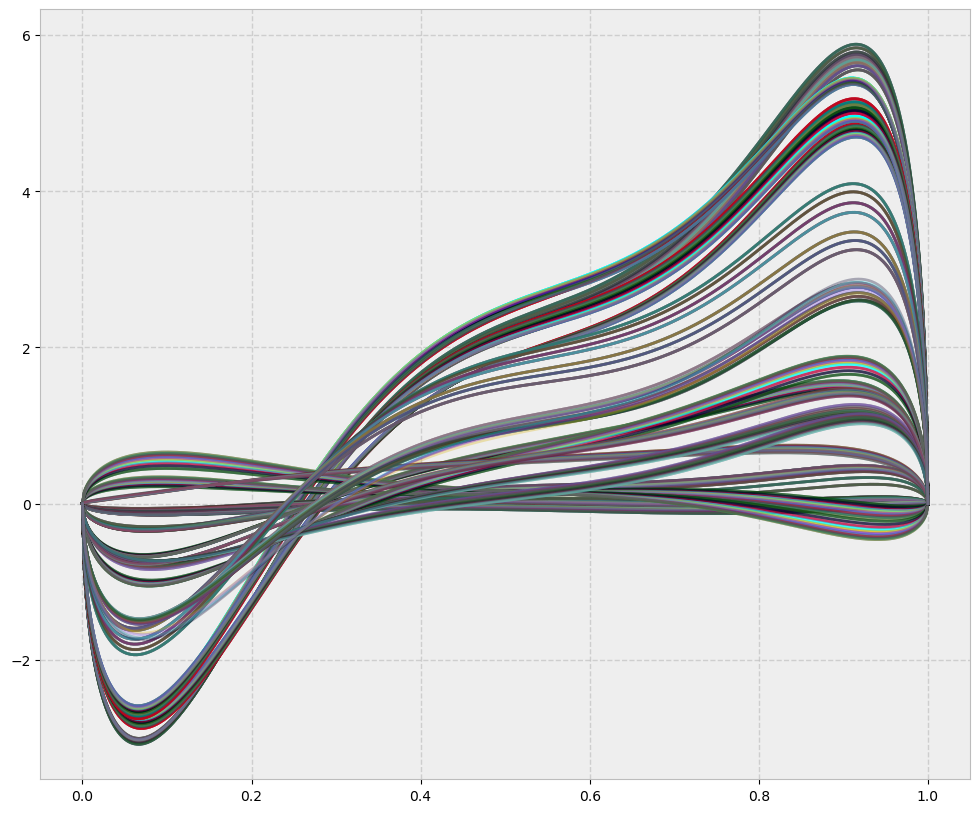

In [102]:
y_np = torch.stack(ys).detach().cpu().numpy()
t_np = t_plot_t.detach().cpu().numpy()
for Y in y_np.T:
    plt.plot(t_np, Y, '-', alpha=0.3)

In [64]:
N = 3
t_plot_t = torch.stack([torch.linspace(0, 1, 1000)]*N, dim=0)
t_plot_t.shape

torch.Size([3, 1000])

# Деревья. Но это не тру

In [108]:
#!pip install catboost

In [116]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from catboost import CatBoostRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error


X_train = df_train_ex.drop(target_col, axis=1)
y_train = df_train_ex[target_col].values

X_test = df_test.drop(target_col, axis=1)
y_test = df_test[target_col].values

# ... (подготовка данных: X_train, X_test, y_train, y_test - матрицы коэффициентов) ...

# === 1. Random Forest ===
# Случайный лес поддерживает многомерный вывод "из коробки"[reference:0]
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f"Random Forest MSE: {mse_rf:.4f}")

# === 2. CatBoost ===
# CatBoost также имеет встроенную поддержку многомерной регрессии (мультирегрессии)[reference:1].
cb_model = CatBoostRegressor(iterations=100, learning_rate=0.1, random_seed=42, verbose=False)
cb_model.fit(X_train, y_train)
y_pred_cb = cb_model.predict(X_test)
mse_cb = mean_squared_error(y_test, y_pred_cb)
print(f"CatBoost MSE: {mse_cb:.4f}")

# === Альтернатива: MultiOutputRegressor ===
# Если по какой-то причине встроенная поддержка не подходит, можно использовать 
# универсальный мета-оценщик MultiOutputRegressor. Он обучит отдельную модель для 
# каждого выходного параметра.
# Это работает и для RandomForest, и для CatBoost.
#multi_rf = MultiOutputRegressor(RandomForestRegressor(n_estimators=100, random_state=42))
#multi_rf.fit(X_train, y_train)
#y_pred_multi = multi_rf.predict(X_test)

Random Forest MSE: 0.1347
CatBoost MSE: 0.0868


# Собственно, символьное обучение

In [ ]:
from pysr import PySRRegressor
model = PySRRegressor(
    #binary_operators=["+", "-", "*", "/", "^"],
    binary_operators=["+", "-", "*"],
    unary_operators=["exp", "square", "log"],
    
    niterations=300,          # можно начать с 300
    populations=30,
    population_size=50,
    ncycles_per_iteration=300,
    maxsize=20,
    maxdepth=5,
    procs=8,                  # использует все ядра
    random_state=42,
    deterministic=False,      # <- отключаем детерминизм для многопоточности
    batching=False,
    turbo=True,
    verbosity=1,               # Уровень детализации вывода
    select_k_features=12, # !!!! не больше входных значений!!!!
    elementwise_loss="L2DistLoss()",
)

In [1]:
!which python

/home/gleb/miniforge3/envs/py312/bin/python


In [ ]:
model.fit(
    df_train,
    y
)